# Modelagem em Dataset de Fraude
- dataset: https://www.kaggle.com/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv
- tipo de problema: Classificação Binária
- modelo: decision tree

### Baixando o arquivo

In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uditjain13/credit-card-fraud-detection-2026")

print("Path to dataset files:", path)

Path to dataset files: /home/leo/.cache/kagglehub/datasets/uditjain13/credit-card-fraud-detection-2026/versions/5


In [31]:
ls /home/leo/.cache/kagglehub/datasets/uditjain13/credit-card-fraud-detection-2026/versions/5

credit_card_fraud_2026.csv


---

## 1. Análise Exploratória

- linhas: 20_000
- fraudes: 339

In [32]:
import pandas as pd

complete_path = f"{path}/credit_card_fraud_2026.csv"
df = pd.read_csv(complete_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

- Sem valores nulos
Features com object:
>  - merchant_category
>  - card_type
>  - auth_method
>  - channel
>  - device_type

In [33]:
df['device_type'].value_counts()

device_type
Android Phone    5503
iPhone           4179
POS Terminal     3162
Windows PC       2623
Mac              1359
Tablet           1161
Smart Watch      1008
ATM Machine      1005
Name: count, dtype: int64

In [34]:
df['channel'].value_counts()

channel
Online         6810
POS            5191
Contactless    3400
In-App         3225
ATM            1374
Name: count, dtype: int64

In [35]:
df['merchant_category'].value_counts()

merchant_category
Online Retail      3416
Groceries          3242
Restaurants        2534
Electronics        2032
Fuel               1565
Travel             1420
Utilities          1330
Healthcare         1237
Gaming             1036
Streaming          1010
Gift Cards          617
Crypto Exchange     561
Name: count, dtype: int64

In [36]:
df['card_type'].value_counts()

card_type
Visa          8417
Mastercard    6629
Amex          2135
RuPay         1796
Discover      1023
Name: count, dtype: int64

In [37]:
df['auth_method'].value_counts() # talvez aqui valeria a pena utilizar um Ordinal Enconding

auth_method
3D Secure            5554
OTP                  4792
PIN                  4173
Biometric            3093
No Authentication    2388
Name: count, dtype: int64

analisando a relação de cada feature com o target

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

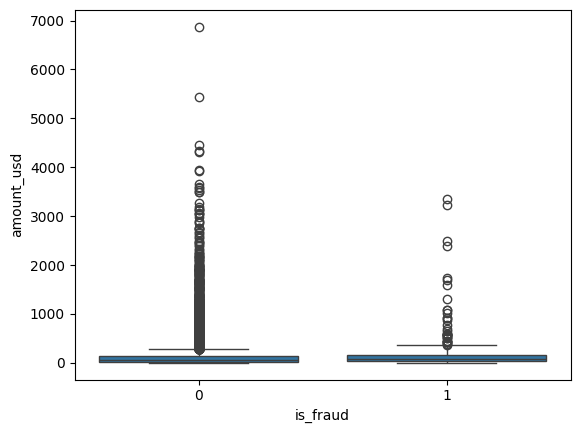

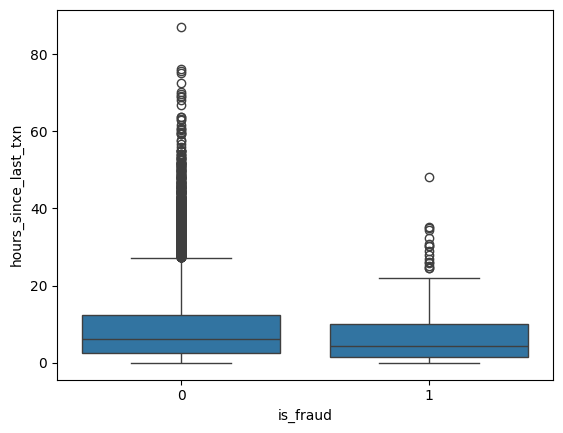

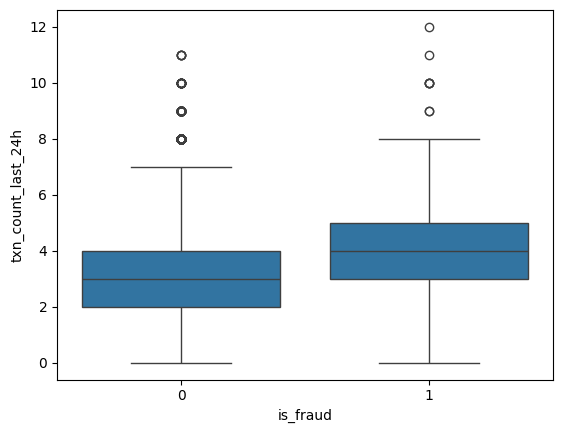

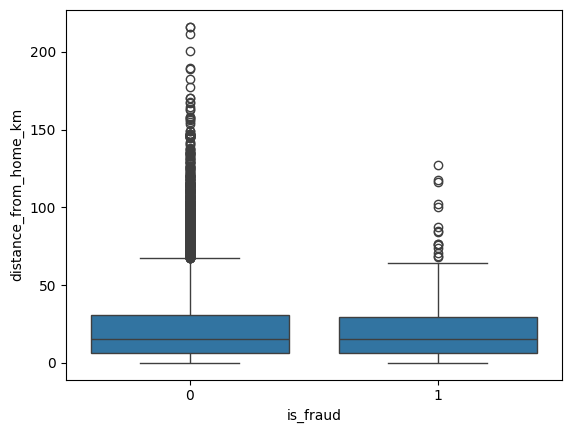

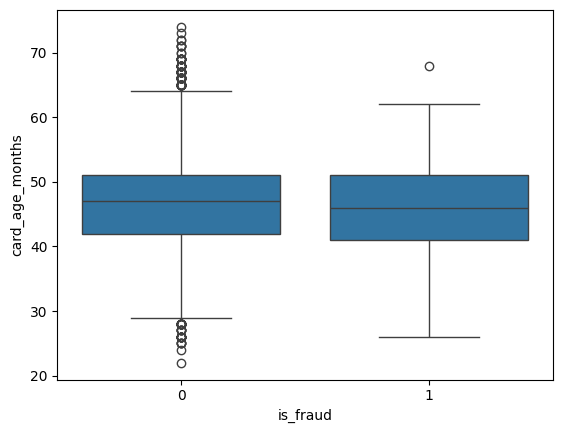

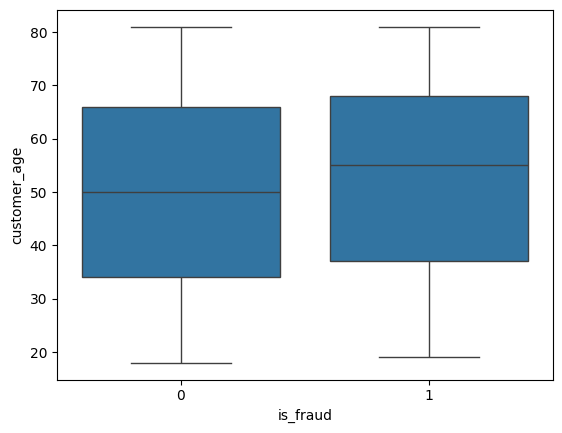

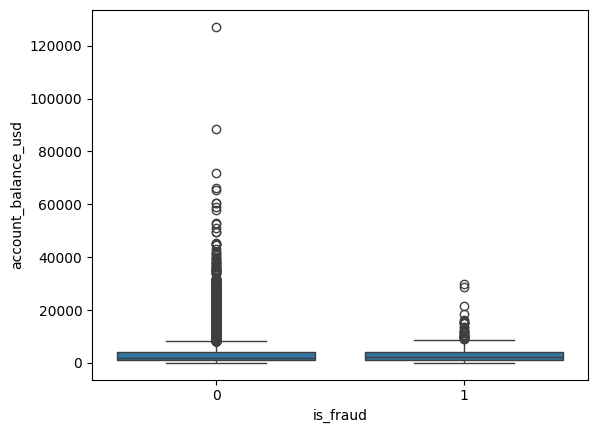

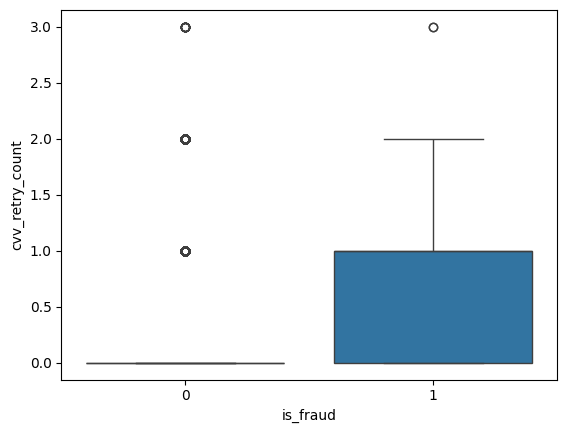

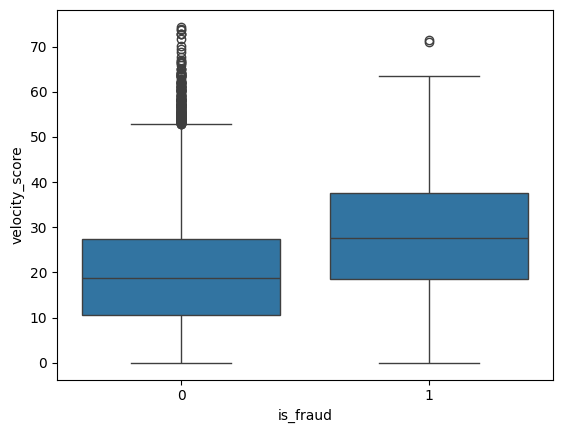

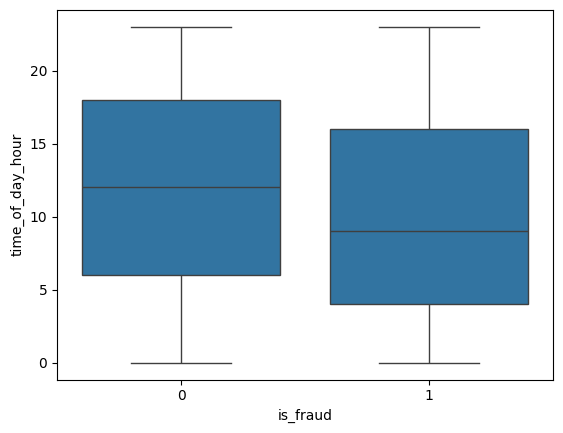

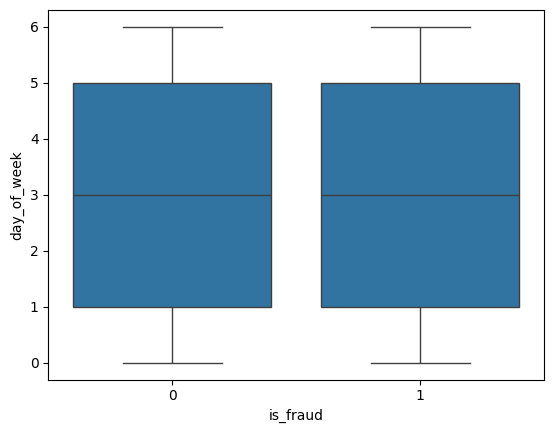

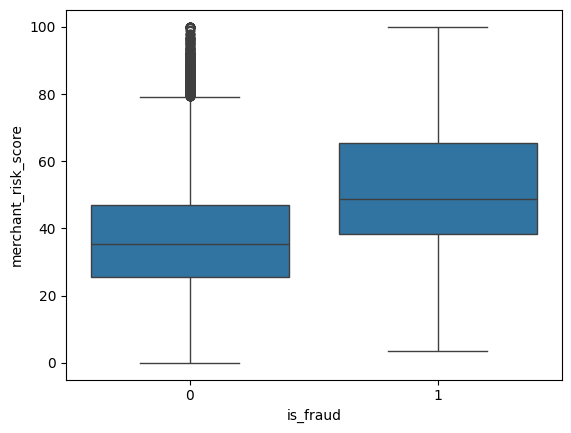

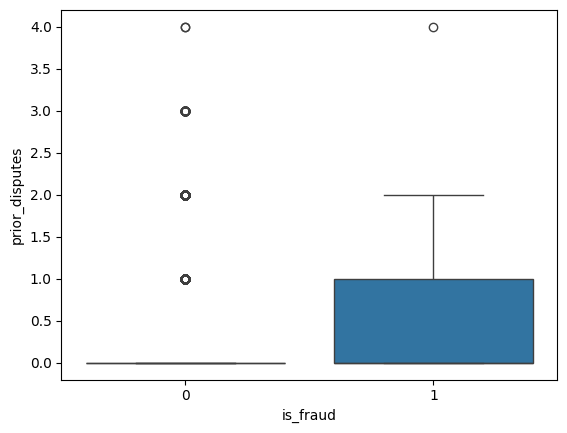

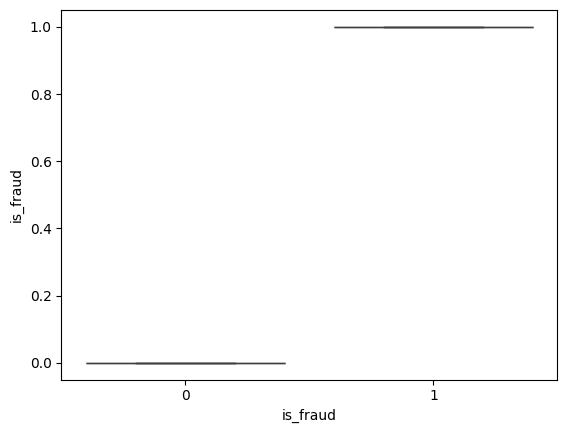

In [39]:
colunas_str = df.select_dtypes(include=['object']).columns
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

for f in colunas_numericas:
    if f == 'transaction_id':
        continue
    sns.boxplot(data= df,
                    x = 'is_fraud',
                    y = f) # aqui a lógica é invertida

    plt.show()

Features com potêncial para descriminar as classes:
- prior_disputes
- cvv_retry_count

Distribuição da variavel resposta

<Axes: xlabel='is_fraud'>

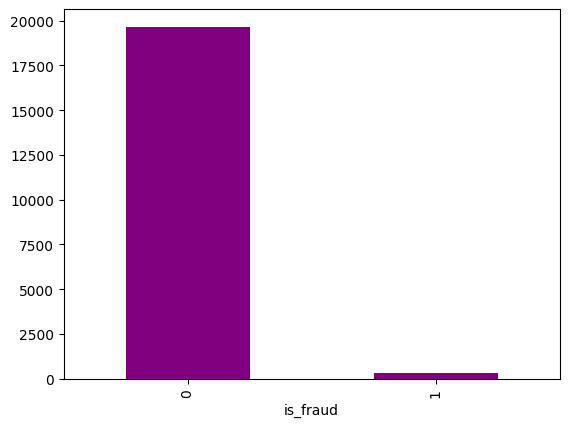

In [40]:
df['is_fraud'].value_counts().plot(kind= 'bar', color='purple')

Classes desbalânceadas, ***não utilizar acurácia***. Utilizar:
- Precision
- Recall
- F1-Score
- ROC e AUC

---

## 2. Pré-Processamento

In [41]:
from sklearn.preprocessing import OneHotEncoder # enconder pra transformar as colunas categoricas
from sklearn.compose import make_column_transformer # retornar ao nome as colunas transformadas
from sklearn.model_selection import train_test_split # separar treino, teste e validação

Transformas as colunas de bools em int/float:

In [42]:
colunas_bools = df.select_dtypes(include = 'bool').columns

df[colunas_bools] = df[colunas_bools].astype(int)

Separando features e target:

In [43]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

Encoder:

In [44]:
try:
    X.drop('transaction_id', axis=1, inplace = True)
except:
    None

colunas_str = X.select_dtypes(include=['object']).columns.to_list()

one_hot = make_column_transformer((
    OneHotEncoder(drop='if_binary'),
    colunas_str
),
remainder= 'passthrough', # este reminder manter as outras colunas
sparse_threshold= 0 # faz com que ele mantenha as colunas com os valores originais
)

Aplicando OneHotEncoder:

In [45]:
colunas_X = X.columns

X = one_hot.fit_transform(X)
one_hot.get_feature_names_out(colunas_X)

X = pd.DataFrame(X, columns= one_hot.get_feature_names_out(colunas_X))

In [46]:
df['auth_method'].value_counts()

auth_method
3D Secure            5554
OTP                  4792
PIN                  4173
Biometric            3093
No Authentication    2388
Name: count, dtype: int64

In [47]:
X['onehotencoder__auth_method_PIN'].value_counts()

onehotencoder__auth_method_PIN
0.0    15827
1.0     4173
Name: count, dtype: int64

In [48]:
# 1ª divisão: separa o conjunto de teste
X, X_teste, y, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 2ª divisão: separa treino e validação
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

---

## 3. Modelagem
**modelo**:
- Decision Tree
- Random Forest
- KNN
- Regressão Logistica

In [86]:
from sklearn.tree import DecisionTreeClassifier # arvore de decisão
from sklearn.tree import plot_tree # plotagem da arvore de decisão para enteder a lógica
from sklearn.neighbors import KNeighborsClassifier # knn
from sklearn.linear_model import LogisticRegression # regressão logistica
from sklearn.ensemble import RandomForestClassifier # random forest

# métricas
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix,roc_auc_score, RocCurveDisplay , ConfusionMatrixDisplay  

Para rodar o KNN precisamos normalizar o dataset já que o KNN usa os valores mais próximos:

In [59]:
from sklearn.preprocessing import StandardScaler

In [70]:
SCALER = StandardScaler()

X_treino_normalizado = SCALER.fit_transform(X_treino)
X_validacao_normalizado = SCALER.transform(X_validacao)
X_teste_normalizado = SCALER.transform(X_teste)

X_treino_normalizado = pd.DataFrame(X_treino_normalizado, columns=X_treino.columns)
X_validacao_normalizado = pd.DataFrame(X_validacao_normalizado, columns=X_validacao.columns)
X_teste_normalizado = pd.DataFrame(X_teste_normalizado, columns=X_teste.columns)

Treinamento dos Modelos:

In [87]:
arvore_decisao = DecisionTreeClassifier(max_depth=3, class_weight='balanced')
modelo_regressao_logistica = LogisticRegression(class_weight='balanced')
modelo_knn = KNeighborsClassifier(n_neighbors=3)
modelo_random_forest = RandomForestClassifier(n_estimators=300)

arvore_decisao.fit(X_treino, y_treino)
modelo_regressao_logistica.fit(X_treino, y_treino)
modelo_knn.fit(X_treino_normalizado, y_treino)

/home/leo/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [62]:
from sklearn.metrics import classification_report

In [83]:
y_previsto_arvore = arvore_decisao.predict(X_validacao)
y_previsto_logistica = modelo_regressao_logistica.predict(X_validacao)
y_previsto_KNN = modelo_knn.predict(X_validacao_normalizado)

In [84]:
print(f'ARVORE: score de treino: {arvore_decisao.score(X_treino,y_treino):.5f}')

print(f'REGRESSAO LOGISTICA: score de treino: {modelo_regressao_logistica.score(X_treino,y_treino):.5f}')

print(f'KNN: score de treino: {modelo_knn.score(X_treino_normalizado,y_treino):.5f}')

ARVORE: score de treino: 0.74594
REGRESSAO LOGISTICA: score de treino: 0.70391
KNN: score de treino: 0.98391


In [85]:
print(f'ARVORE\n{classification_report(y_validacao, y_previsto_arvore)}')
print(170*"=")
print(f'REGRESSAO LOGISTICA\n{classification_report(y_validacao, y_previsto_logistica)}')
print(170*"=")
print(f'KNN\n{classification_report(y_validacao, y_previsto_KNN)}')

ARVORE
              precision    recall  f1-score   support

           0       0.99      0.75      0.85      3152
           1       0.04      0.75      0.08        48

    accuracy                           0.75      3200
   macro avg       0.52      0.75      0.47      3200
weighted avg       0.98      0.75      0.84      3200

REGRESSAO LOGISTICA
              precision    recall  f1-score   support

           0       1.00      0.70      0.82      3152
           1       0.04      0.79      0.07        48

    accuracy                           0.70      3200
   macro avg       0.52      0.75      0.45      3200
weighted avg       0.98      0.70      0.81      3200

KNN
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3152
           1       0.00      0.00      0.00        48

    accuracy                           0.98      3200
   macro avg       0.49      0.50      0.50      3200
weighted avg       0.97      0.98      0.98

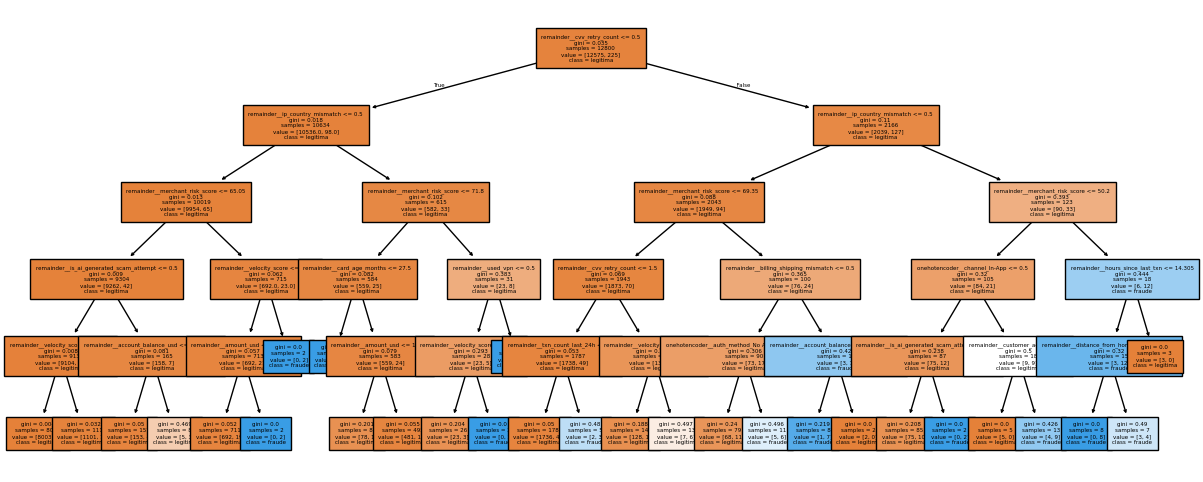

In [53]:
colunas_lista = list()
for coluna in X.columns:
    colunas_lista.append(coluna)
    
plt.figure(figsize = (15,6))
plot_tree(arvore_decisao, filled = True, class_names = ['legitima', 'fraude'], fontsize = 4, feature_names = colunas_lista);